In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path
from collections import Counter

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.base import clone

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
)

# Optional
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from fairlearn.metrics import (
        MetricFrame,
        false_negative_rate,
        selection_rate,
        true_positive_rate,
        false_positive_rate,
        count,
    )
    from fairlearn.postprocessing import ThresholdOptimizer
    HAS_FAIRLEARN = True
except Exception:
    HAS_FAIRLEARN = False


DATA_PATH = Path("/Users/kayadetunji/Documents/AWI_GEN_PROJECT/cvd_data_awigenv1.csv")

DROP_COLS = [
    "Unnamed: 0", "study_id", "chf_meds_qc", "angina_meds_qc",
    "pain_action_stop_or_slow_qc", "pain_action_rest_qc",
    "pain_action_medicine_qc", "pain_action_carry_on_qc",
    "relief_standstill_qc", "relief_standstill_qc.1",
    "pain_location_1_qc", "pain_location_2_qc", "pain_location_3_qc",
    "pain_location_4_qc", "pain_location_5_qc", "pain_location_6_qc",
    "pain_location_7_qc", "pain_location_8_qc", "pain_location_9_qc",
    "pain_location_10_qc", "pain_location_11_qc", "pain_location_12_qc",
    "pain_location_13_qc", "pain_location_14_qc", "pain_location_15_qc",
    "pain_location_16_qc", "pain_location_17_qc", "pain_location_18_qc",
    "angina_treat_now_qc", "angina_traditional_qc", "pain_qc", "pain2_qc",
]

PREDICTOR_COLS = [
    "site", "age", "sex", "number_of_children_c",
    "partnership_status_c_qc", "highest_level_of_education_qc", "occupation_qc",
    "ses_site_quintile_c_qc", "smoking_status_c_qc", "alcohol_use_status_c_qc",
    "avg_sleep_per_night_c", "mvpa_c", "obesity_mom_qc", "hiv_final_status_c",
    "pesticide_qc", "waist_circumference_qc", "hip_circumference_qc",
    "waist_hip_r_c_qc", "bp_sys_average_qc", "pulse_average_qc",
    "visceral_fat_qc", "subcutaneous_fat_qc", "mean_cimt_right_qc",
    "mean_cimt_left_qc", "ldl_qc", "triglycerides_qc",
    "acr_qc", "bmi_c_qc", "cholesterol_1_qc",
]

CVD_COMPONENTS = [
    "stroke_qc",
    "transient_ischemic_attack_qc",
    "heartattack_qc",
    "congestive_heart_failure_qc",
    "angina_qc",
]

SENTINELS = [-999, -222, -111]


def make_cvd_outcome(df, components, mode="strict"):
    """
    Composite CVD outcome.

    strict:
        1 if any component == 1
        0 if all components are observed and all == 0
        NaN otherwise

    lenient:
        1 if any component == 1
        0 if at least one component is observed, none is 1, and observed values are 0
        NaN if all components are missing

    Strict is safer. Lenient is closer to the earlier prototype.
    """
    comp = df[components].replace(SENTINELS, np.nan)

    any_positive = comp.eq(1).any(axis=1)
    all_observed_zero = comp.notna().all(axis=1) & comp.eq(0).all(axis=1)
    any_observed = comp.notna().any(axis=1)
    no_positive_observed = ~any_positive

    if mode == "strict":
        y = pd.Series(np.nan, index=df.index, name="CVD")
        y.loc[any_positive] = 1
        y.loc[all_observed_zero] = 0
        return y

    if mode == "lenient":
        y = pd.Series(np.nan, index=df.index, name="CVD")
        y.loc[any_positive] = 1
        y.loc[any_observed & no_positive_observed] = 0
        return y

    raise ValueError("mode must be 'strict' or 'lenient'")


df_raw = pd.read_csv(DATA_PATH)
df = df_raw.drop(columns=[c for c in DROP_COLS if c in df_raw.columns], errors="ignore")
df = df.replace(SENTINELS, np.nan)

y_strict = make_cvd_outcome(df, CVD_COMPONENTS, mode="strict")
y_lenient = make_cvd_outcome(df, CVD_COMPONENTS, mode="lenient")

print("Strict outcome counts:")
print(y_strict.value_counts(dropna=False))

print("\nLenient outcome counts:")
print(y_lenient.value_counts(dropna=False))

Strict outcome counts:
0.0    6714
NaN    4875
1.0     443
Name: CVD, dtype: int64

Lenient outcome counts:
0.0    10578
NaN     1011
1.0      443
Name: CVD, dtype: int64


In [2]:
# Start with lenient if strict drops too many people.
# Later, we can run strict as sensitivity analysis.
OUTCOME_MODE = "lenient"

df["CVD"] = y_lenient if OUTCOME_MODE == "lenient" else y_strict

analysis_df = df.dropna(subset=["CVD"]).copy()
analysis_df["CVD"] = analysis_df["CVD"].astype(int)

available_predictors = [c for c in PREDICTOR_COLS if c in analysis_df.columns]

# Keep site and sex for subgroup/fairness analysis.
# For primary modelling, we can exclude site to test transferability honestly.
SENSITIVE_COLS = ["sex", "site"]

numeric_cols = [
    "age", "number_of_children_c", "avg_sleep_per_night_c",
    "waist_circumference_qc", "hip_circumference_qc", "waist_hip_r_c_qc",
    "bp_sys_average_qc", "pulse_average_qc", "visceral_fat_qc",
    "subcutaneous_fat_qc", "mean_cimt_right_qc", "mean_cimt_left_qc",
    "ldl_qc", "triglycerides_qc", "acr_qc", "bmi_c_qc", "cholesterol_1_qc",
]

categorical_cols = [
    "site", "sex", "partnership_status_c_qc", "highest_level_of_education_qc",
    "occupation_qc", "ses_site_quintile_c_qc", "smoking_status_c_qc",
    "alcohol_use_status_c_qc", "mvpa_c", "obesity_mom_qc",
    "hiv_final_status_c", "pesticide_qc",
]

numeric_cols = [c for c in numeric_cols if c in available_predictors]
categorical_cols = [c for c in categorical_cols if c in available_predictors]

PRIMARY_EXCLUDE = ["site"]  # primary model excludes site; we evaluate fairness/transfer by site
feature_cols = [c for c in available_predictors if c not in PRIMARY_EXCLUDE]

numeric_features = [c for c in numeric_cols if c in feature_cols]
categorical_features = [c for c in categorical_cols if c in feature_cols]

print("N:", len(analysis_df))
print("Outcome prevalence:")
print(analysis_df["CVD"].value_counts(normalize=True).rename("proportion"))
print("\nSites:")
print(analysis_df["site"].value_counts(dropna=False))
print("\nSex:")
print(analysis_df["sex"].value_counts(dropna=False))

profile_table = pd.DataFrame({
    "N": [len(analysis_df)],
    "CVD_positive": [int(analysis_df["CVD"].sum())],
    "CVD_negative": [int((analysis_df["CVD"] == 0).sum())],
    "CVD_prevalence": [analysis_df["CVD"].mean()],
    "n_sites": [analysis_df["site"].nunique(dropna=True)]
})

display(profile_table)

N: 11021
Outcome prevalence:
0    0.959804
1    0.040196
Name: proportion, dtype: float64

Sites:
1    2486
4    2091
5    2016
3    2003
2    1398
6    1027
Name: site, dtype: int64

Sex:
0    5618
1    5403
Name: sex, dtype: int64


,N,CVD_positive,CVD_negative,CVD_prevalence,n_sites
0,11021,443,10578,0.040196,6


In [3]:
def make_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(numeric_features, categorical_features):
    numeric_pipe = Pipeline(steps=[
        ("imputer", IterativeImputer(
            estimator=BayesianRidge(),
            max_iter=10,
            initial_strategy="mean",
            random_state=42,
            skip_complete=True
        )),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot())
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop"
    )


def make_models(random_state=42):
    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000, random_state=random_state),
        "Logistic Regression (balanced)": LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=random_state
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=500, random_state=random_state, n_jobs=-1
        ),
        "Random Forest (balanced)": RandomForestClassifier(
            n_estimators=500, class_weight="balanced", random_state=random_state, n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingClassifier(random_state=random_state),
    }

    if HAS_XGB:
        models["XGBoost"] = xgb.XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=-1
        )

    return models


def safe_divide(a, b):
    return np.nan if b == 0 else a / b


def evaluate_binary(y_true, y_pred, y_score=None):
    y_true = pd.Series(y_true).astype(int)
    y_pred = pd.Series(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    out = {
        "n": len(y_true),
        "positives": int(y_true.sum()),
        "prevalence": y_true.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "sensitivity_recall_TPR": safe_divide(tp, tp + fn),
        "specificity_TNR": safe_divide(tn, tn + fp),
        "false_negative_rate": safe_divide(fn, fn + tp),
        "false_positive_rate": safe_divide(fp, fp + tn),
        "precision_PPV": safe_divide(tp, tp + fp),
        "NPV": safe_divide(tn, tn + fn),
        "false_negatives_per_1000": safe_divide(fn, len(y_true)) * 1000,
        "false_positives_per_1000": safe_divide(fp, len(y_true)) * 1000,
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        out["AUROC"] = roc_auc_score(y_true, y_score)
        out["PR_AUC"] = average_precision_score(y_true, y_score)
        out["Brier_score"] = brier_score_loss(y_true, y_score)
    else:
        out["AUROC"] = np.nan
        out["PR_AUC"] = np.nan
        out["Brier_score"] = np.nan

    return out


def make_pipeline(estimator):
    preprocessor = make_preprocessor(numeric_features, categorical_features)
    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", estimator)
    ])

In [4]:
X = analysis_df[feature_cols].copy()
y = analysis_df["CVD"].copy()
groups = analysis_df[SENSITIVE_COLS].copy()

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups,
    test_size=0.20,
    stratify=y,
    random_state=42
)

models = make_models()
pooled_results = []
trained_models = {}

for model_name, estimator in models.items():
    pipe = make_pipeline(estimator)
    pipe.fit(X_train, y_train)

    y_score = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_score >= 0.50).astype(int)

    result = evaluate_binary(y_test, y_pred, y_score)
    result["model"] = model_name
    pooled_results.append(result)
    trained_models[model_name] = pipe

pooled_results_df = pd.DataFrame(pooled_results).sort_values(
    by=["PR_AUC", "balanced_accuracy"], ascending=False
)

display(pooled_results_df)

,n,positives,prevalence,accuracy,balanced_accuracy,sensitivity_recall_TPR,specificity_TNR,false_negative_rate,false_positive_rate,precision_PPV,NPV,false_negatives_per_1000,false_positives_per_1000,AUROC,PR_AUC,Brier_score,model
5,2205,89,0.040363,0.959637,0.500000,0.000000,1.000000,1.000000,0.000000,NaN,0.959637,40.362812,0.000000,0.630599,0.070513,0.038722,XGBoost
3,2205,89,0.040363,0.959637,0.500000,0.000000,1.000000,1.000000,0.000000,NaN,0.959637,40.362812,0.000000,0.641238,0.067252,0.038425,Random Forest (balanced)
2,2205,89,0.040363,0.959637,0.500000,0.000000,1.000000,1.000000,0.000000,NaN,0.959637,40.362812,0.000000,0.664575,0.065870,0.038453,Random Forest
0,2205,89,0.040363,0.959637,0.500000,0.000000,1.000000,1.000000,0.000000,NaN,0.959637,40.362812,0.000000,0.642600,0.062496,0.038645,Logistic Regression
4,2205,89,0.040363,0.957370,0.498819,0.000000,0.997637,1.000000,0.002363,0.00000,0.959545,40.362812,2.267574,0.643431,0.060467,0.040585,Gradient Boosting
1,2205,89,0.040363,0.648526,0.580077,0.505618,0.654537,0.494382,0.345463,0.05799,0.969209,19.954649,331.519274,0.615078,0.060465,0.204495,Logistic Regression (balanced)


In [5]:
def group_metrics_table(y_true, y_pred, y_score, group_series, group_name):
    rows = []
    tmp = pd.DataFrame({
        "y_true": np.asarray(y_true).astype(int),
        "y_pred": np.asarray(y_pred).astype(int),
        "y_score": np.asarray(y_score),
        "group": np.asarray(group_series)
    })

    for group_value, sub in tmp.groupby("group", dropna=False):
        if len(sub) < 10:
            continue

        metrics = evaluate_binary(sub["y_true"], sub["y_pred"], sub["y_score"])
        metrics[group_name] = group_value
        rows.append(metrics)

    return pd.DataFrame(rows)


# Choose the best model from pooled table
BEST_MODEL_NAME = pooled_results_df.iloc[0]["model"]
best_model = trained_models[BEST_MODEL_NAME]

y_score_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_score_best >= 0.50).astype(int)

print("Best model:", BEST_MODEL_NAME)

site_metrics = group_metrics_table(
    y_test, y_pred_best, y_score_best,
    groups_test["site"], "site"
)

sex_metrics = group_metrics_table(
    y_test, y_pred_best, y_score_best,
    groups_test["sex"], "sex"
)

display(site_metrics.sort_values("false_negative_rate", ascending=False))
display(sex_metrics.sort_values("false_negative_rate", ascending=False))

Best model: XGBoost


,n,positives,prevalence,accuracy,balanced_accuracy,sensitivity_recall_TPR,specificity_TNR,false_negative_rate,false_positive_rate,precision_PPV,NPV,false_negatives_per_1000,false_positives_per_1000,AUROC,PR_AUC,Brier_score,site
0,521,27,0.051823,0.948177,0.5,0.0,1.0,1.0,0.0,NaN,0.948177,51.823417,0.0,0.543335,0.064199,0.050017,1
1,272,20,0.073529,0.926471,0.5,0.0,1.0,1.0,0.0,NaN,0.926471,73.529412,0.0,0.472024,0.122780,0.069337,2
2,385,22,0.057143,0.942857,0.5,0.0,1.0,1.0,0.0,NaN,0.942857,57.142857,0.0,0.580391,0.117900,0.054029,3
3,416,6,0.014423,0.985577,0.5,0.0,1.0,1.0,0.0,NaN,0.985577,14.423077,0.0,0.699187,0.067831,0.014110,4
4,405,8,0.019753,0.980247,0.5,0.0,1.0,1.0,0.0,NaN,0.980247,19.753086,0.0,0.724811,0.065429,0.019137,5
5,206,6,0.029126,0.970874,0.5,0.0,1.0,1.0,0.0,NaN,0.970874,29.126214,0.0,0.390833,0.026569,0.029335,6


,n,positives,prevalence,accuracy,balanced_accuracy,sensitivity_recall_TPR,specificity_TNR,false_negative_rate,false_positive_rate,precision_PPV,NPV,false_negatives_per_1000,false_positives_per_1000,AUROC,PR_AUC,Brier_score,sex
0,1104,52,0.047101,0.952899,0.5,0.0,1.0,1.0,0.0,NaN,0.952899,47.101449,0.0,0.651653,0.074524,0.044709,0
1,1101,37,0.033606,0.966394,0.5,0.0,1.0,1.0,0.0,NaN,0.966394,33.605813,0.0,0.582123,0.068115,0.032720,1


In [6]:
def leave_one_site_out_validation(df, feature_cols, outcome_col="CVD", site_col="site", model_name=None):
    rows = []

    if model_name is None:
        model_name = BEST_MODEL_NAME

    estimator = make_models()[model_name]

    for heldout_site in sorted(df[site_col].dropna().unique()):
        train_df = df[df[site_col] != heldout_site].copy()
        test_df = df[df[site_col] == heldout_site].copy()

        if test_df[outcome_col].nunique() < 2:
            print(f"Skipping {heldout_site}: held-out site has only one outcome class.")
            continue

        X_train_site = train_df[feature_cols]
        y_train_site = train_df[outcome_col].astype(int)

        X_test_site = test_df[feature_cols]
        y_test_site = test_df[outcome_col].astype(int)

        pipe = make_pipeline(clone(estimator))
        pipe.fit(X_train_site, y_train_site)

        y_score_site = pipe.predict_proba(X_test_site)[:, 1]
        y_pred_site = (y_score_site >= 0.50).astype(int)

        result = evaluate_binary(y_test_site, y_pred_site, y_score_site)
        result["heldout_site"] = heldout_site
        result["train_n"] = len(train_df)
        result["test_n"] = len(test_df)
        result["model"] = model_name

        rows.append(result)

    return pd.DataFrame(rows)


loso_results = leave_one_site_out_validation(
    analysis_df,
    feature_cols=feature_cols,
    outcome_col="CVD",
    site_col="site",
    model_name=BEST_MODEL_NAME
)

display(loso_results.sort_values("PR_AUC", ascending=True))

,n,positives,prevalence,accuracy,balanced_accuracy,sensitivity_recall_TPR,specificity_TNR,false_negative_rate,false_positive_rate,precision_PPV,NPV,false_negatives_per_1000,false_positives_per_1000,AUROC,PR_AUC,Brier_score,heldout_site,train_n,test_n,model
3,2091,31,0.014825,0.985175,0.5,0.0,1.0,1.0,0.0,NaN,0.985175,14.825442,0.0,0.536580,0.017374,0.015040,4,8930,2091,XGBoost
5,1027,36,0.035054,0.964946,0.5,0.0,1.0,1.0,0.0,NaN,0.964946,35.053554,0.0,0.555499,0.041224,0.034761,6,9994,1027,XGBoost
2,2003,85,0.042436,0.957564,0.5,0.0,1.0,1.0,0.0,NaN,0.957564,42.436345,0.0,0.483751,0.043623,0.041579,3,9018,2003,XGBoost
4,2016,51,0.025298,0.974702,0.5,0.0,1.0,1.0,0.0,NaN,0.974702,25.297619,0.0,0.574565,0.044010,0.024634,5,9005,2016,XGBoost
0,2486,141,0.056718,0.943282,0.5,0.0,1.0,1.0,0.0,NaN,0.943282,56.717619,0.0,0.543229,0.062601,0.054576,1,8535,2486,XGBoost
1,1398,99,0.070815,0.929185,0.5,0.0,1.0,1.0,0.0,NaN,0.929185,70.815451,0.0,0.570703,0.097889,0.066300,2,9623,1398,XGBoost


In [7]:
if not HAS_FAIRLEARN:
    print("Fairlearn is not installed. Install with: pip install fairlearn")
else:
    # Refit a base model on the same train split
    base_model = make_pipeline(clone(models[BEST_MODEL_NAME]))
    base_model.fit(X_train, y_train)

    y_score_base = base_model.predict_proba(X_test)[:, 1]
    y_pred_base = (y_score_base >= 0.50).astype(int)

    metrics_dict = {
        "selection_rate": selection_rate,
        "false_negative_rate": false_negative_rate,
        "true_positive_rate": true_positive_rate,
        "false_positive_rate": false_positive_rate,
        "balanced_accuracy": balanced_accuracy_score,
        "count": count,
    }

    mf_site_unmitigated = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_pred_base,
        sensitive_features=groups_test["site"]
    )

    display(mf_site_unmitigated.by_group)
    display(pd.DataFrame({
        "difference": mf_site_unmitigated.difference(),
        "ratio": mf_site_unmitigated.ratio(),
        "group_min": mf_site_unmitigated.group_min(),
        "group_max": mf_site_unmitigated.group_max(),
    }))

    # Site-aware postprocessing: tries to reduce false-negative-rate disparity by site.
    site_threshold_optimizer = ThresholdOptimizer(
        estimator=base_model,
        constraints="false_negative_rate_parity",
        objective="balanced_accuracy_score",
        prefit=True,
        predict_method="predict_proba"
    )

    site_threshold_optimizer.fit(
        X_train,
        y_train,
        sensitive_features=groups_train["site"]
    )

    y_pred_site_mitigated = site_threshold_optimizer.predict(
        X_test,
        sensitive_features=groups_test["site"]
    )

    mf_site_mitigated = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_pred_site_mitigated,
        sensitive_features=groups_test["site"]
    )

    print("Unmitigated by site:")
    display(mf_site_unmitigated.by_group)

    print("Site-mitigated by site:")
    display(mf_site_mitigated.by_group)

    print("Unmitigated vs mitigated differences:")
    comparison = pd.concat(
        [
            mf_site_unmitigated.difference().rename("Unmitigated_difference"),
            mf_site_mitigated.difference().rename("Site_mitigated_difference")
        ],
        axis=1
    )
    display(comparison)

,selection_rate,false_negative_rate,true_positive_rate,false_positive_rate,balanced_accuracy,count
site,,,,,,
1,0.0,1.0,0.0,0.0,0.5,521.0
2,0.0,1.0,0.0,0.0,0.5,272.0
3,0.0,1.0,0.0,0.0,0.5,385.0
4,0.0,1.0,0.0,0.0,0.5,416.0
5,0.0,1.0,0.0,0.0,0.5,405.0
6,0.0,1.0,0.0,0.0,0.5,206.0


ZeroDivisionError: float division by zero

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

from imblearn.under_sampling import (
    RandomUnderSampler,
    ClusterCentroids,
    NearMiss,
    NeighbourhoodCleaningRule,
    CondensedNearestNeighbour,
)

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    HAS_OVERSAMPLERS = True
except Exception:
    HAS_OVERSAMPLERS = False

In [9]:
DATA_PATH = Path("/Users/kayadetunji/Documents/AWI_GEN_PROJECT/cvd_data_awigenv1.csv")

SENTINELS = [-999, -222, -111]

PREDICTOR_COLS = [
    "site", "age", "sex", "number_of_children_c",
    "partnership_status_c_qc", "highest_level_of_education_qc", "occupation_qc",
    "ses_site_quintile_c_qc", "smoking_status_c_qc", "alcohol_use_status_c_qc",
    "avg_sleep_per_night_c", "mvpa_c", "obesity_mom_qc", "hiv_final_status_c",
    "pesticide_qc", "waist_circumference_qc", "hip_circumference_qc",
    "waist_hip_r_c_qc", "bp_sys_average_qc", "pulse_average_qc",
    "visceral_fat_qc", "subcutaneous_fat_qc", "mean_cimt_right_qc",
    "mean_cimt_left_qc", "ldl_qc", "triglycerides_qc",
    "acr_qc", "bmi_c_qc", "cholesterol_1_qc"
]

CVD_COMPONENTS = [
    "stroke_qc",
    "transient_ischemic_attack_qc",
    "heartattack_qc",
    "congestive_heart_failure_qc",
    "angina_qc",
]

df = pd.read_csv(DATA_PATH).replace(SENTINELS, np.nan)

def make_cvd_outcome(df, components, mode="lenient"):
    comp = df[components].replace(SENTINELS, np.nan)

    any_positive = comp.eq(1).any(axis=1)
    any_observed = comp.notna().any(axis=1)
    no_positive_observed = ~any_positive
    all_observed_zero = comp.notna().all(axis=1) & comp.eq(0).all(axis=1)

    y = pd.Series(np.nan, index=df.index, name="CVD")

    if mode == "strict":
        y.loc[any_positive] = 1
        y.loc[all_observed_zero] = 0
    elif mode == "lenient":
        y.loc[any_positive] = 1
        y.loc[any_observed & no_positive_observed] = 0
    else:
        raise ValueError("mode must be 'strict' or 'lenient'")

    return y

df["CVD"] = make_cvd_outcome(df, CVD_COMPONENTS, mode="lenient")
analysis_df = df.dropna(subset=["CVD"]).copy()
analysis_df["CVD"] = analysis_df["CVD"].astype(int)

available_predictors = [c for c in PREDICTOR_COLS if c in analysis_df.columns]
X = analysis_df[available_predictors].copy()
y = analysis_df["CVD"].copy()

class_summary = (
    y.value_counts()
    .rename(index={0: "No CVD", 1: "CVD"})
    .to_frame("count")
)
class_summary["percent"] = 100 * class_summary["count"] / class_summary["count"].sum()

display(class_summary)

,count,percent
No CVD,10578,95.980401
CVD,443,4.019599


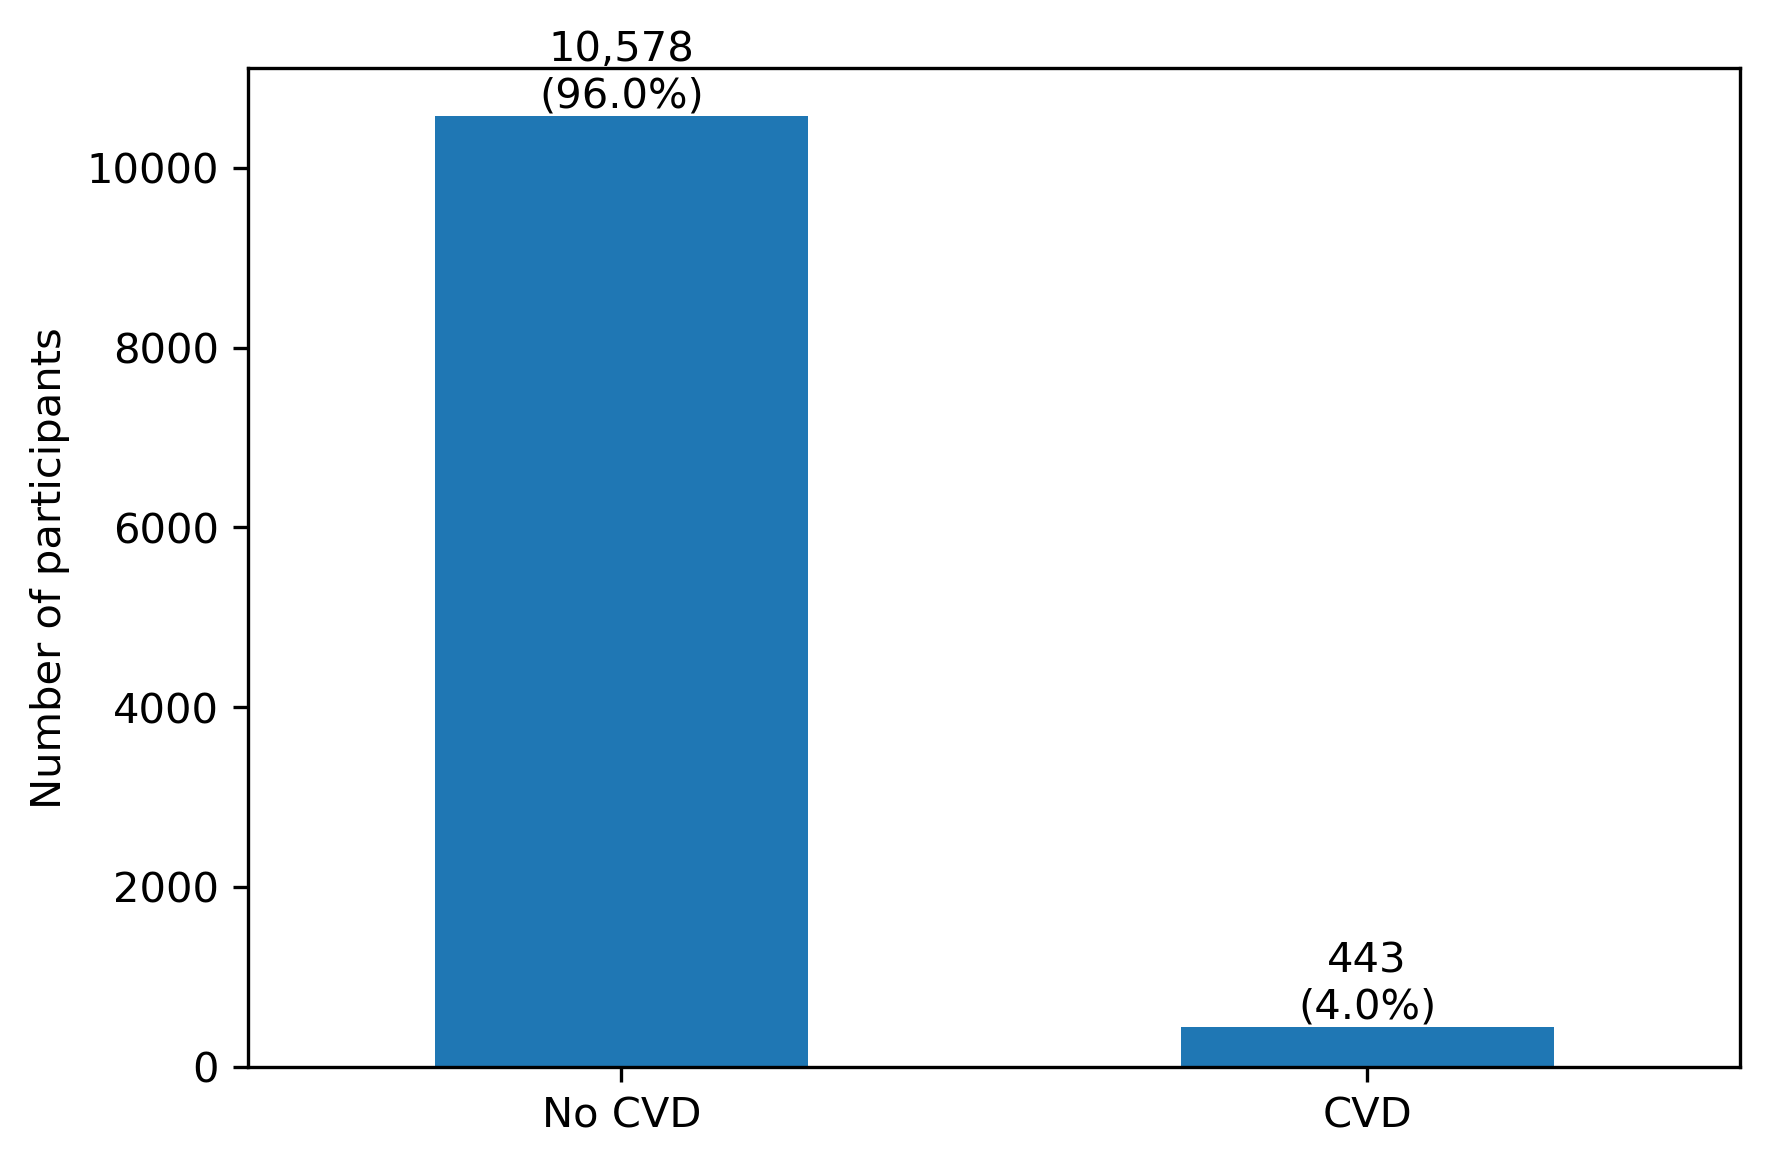

In [11]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

class_summary["count"].plot(kind="bar", ax=ax)

# ax.set_title("CVD outcome distribution")
ax.set_ylabel("Number of participants")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)

for i, (count, pct) in enumerate(zip(class_summary["count"], class_summary["percent"])):
    ax.text(i, count, f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [12]:
def binary_metrics(y_true, y_pred, y_score=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "sensitivity_recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "precision": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        "false_negatives": fn,
        "false_positives": fp,
        "false_negatives_per_1000": 1000 * fn / len(y_true),
        "false_positives_per_1000": 1000 * fp / len(y_true),
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        out["AUROC"] = roc_auc_score(y_true, y_score)
        out["PR_AUC"] = average_precision_score(y_true, y_score)
    else:
        out["AUROC"] = np.nan
        out["PR_AUC"] = np.nan

    return out

In [13]:
numeric_cols = [
    "age", "number_of_children_c", "avg_sleep_per_night_c",
    "waist_circumference_qc", "hip_circumference_qc", "waist_hip_r_c_qc",
    "bp_sys_average_qc", "pulse_average_qc", "visceral_fat_qc",
    "subcutaneous_fat_qc", "mean_cimt_right_qc", "mean_cimt_left_qc",
    "ldl_qc", "triglycerides_qc", "acr_qc", "bmi_c_qc", "cholesterol_1_qc"
]
categorical_cols = [
    "site", "sex", "partnership_status_c_qc", "highest_level_of_education_qc",
    "occupation_qc", "ses_site_quintile_c_qc", "smoking_status_c_qc",
    "alcohol_use_status_c_qc", "mvpa_c", "obesity_mom_qc",
    "hiv_final_status_c", "pesticide_qc"
]

numeric_cols = [c for c in numeric_cols if c in X.columns]
categorical_cols = [c for c in categorical_cols if c in X.columns]

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", IterativeImputer(
                estimator=BayesianRidge(),
                max_iter=10,
                random_state=42,
                initial_strategy="mean"
            )),
            ("scaler", StandardScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ]), categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

baseline_pred = np.zeros_like(y_test)
baseline_metrics = binary_metrics(y_test, baseline_pred)
baseline_metrics["model"] = "Predict all No CVD"
baseline_metrics["threshold"] = "N/A"

lr_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

lr_balanced_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

lr_model.fit(X_train, y_train)
lr_balanced_model.fit(X_train, y_train)

rows = [baseline_metrics]

for name, model in [
    ("Logistic Regression", lr_model),
    ("Logistic Regression class_weight=balanced", lr_balanced_model)
]:
    score = model.predict_proba(X_test)[:, 1]
    pred_05 = (score >= 0.50).astype(int)

    metrics = binary_metrics(y_test, pred_05, score)
    metrics["model"] = name
    metrics["threshold"] = 0.50
    rows.append(metrics)

accuracy_paradox_table = pd.DataFrame(rows)[[
    "model", "threshold", "accuracy", "balanced_accuracy",
    "sensitivity_recall", "specificity", "false_negative_rate",
    "precision", "false_negatives_per_1000", "AUROC", "PR_AUC"
]]

display(accuracy_paradox_table)

,model,threshold,accuracy,balanced_accuracy,sensitivity_recall,specificity,false_negative_rate,precision,false_negatives_per_1000,AUROC,PR_AUC
0,Predict all No CVD,N/A,0.959637,0.500000,0.000000,1.000000,1.000000,NaN,40.362812,NaN,NaN
1,Logistic Regression,0.5,0.959637,0.500000,0.000000,1.000000,1.000000,NaN,40.362812,0.651000,0.062792
2,Logistic Regression class_weight=balanced,0.5,0.649887,0.602313,0.550562,0.654064,0.449438,0.06274,18.140590,0.619687,0.061066


In [14]:
def threshold_sweep(y_true, y_score, thresholds=np.linspace(0.01, 0.99, 99)):
    rows = []

    for thr in thresholds:
        y_pred = (y_score >= thr).astype(int)
        m = binary_metrics(y_true, y_pred, y_score=None)
        m["threshold"] = thr
        rows.append(m)

    return pd.DataFrame(rows)

score_bal = lr_balanced_model.predict_proba(X_test)[:, 1]
threshold_df = threshold_sweep(y_test, score_bal)

display(threshold_df.head())

,accuracy,balanced_accuracy,sensitivity_recall,specificity,false_negative_rate,false_positive_rate,precision,false_negatives,false_positives,false_negatives_per_1000,false_positives_per_1000,AUROC,PR_AUC,threshold
0,0.040816,0.500236,1.000000,0.000473,0.000000,0.999527,0.040381,0,2115,0.000000,959.183673,NaN,NaN,0.01
1,0.043537,0.501654,1.000000,0.003308,0.000000,0.996692,0.040491,0,2109,0.000000,956.462585,NaN,NaN,0.02
2,0.051701,0.505907,1.000000,0.011815,0.000000,0.988185,0.040826,0,2091,0.000000,948.299320,NaN,NaN,0.03
3,0.063039,0.511815,1.000000,0.023629,0.000000,0.976371,0.041299,0,2066,0.000000,936.961451,NaN,NaN,0.04
4,0.073016,0.511632,0.988764,0.034499,0.011236,0.965501,0.041295,1,2043,0.453515,926.530612,NaN,NaN,0.05


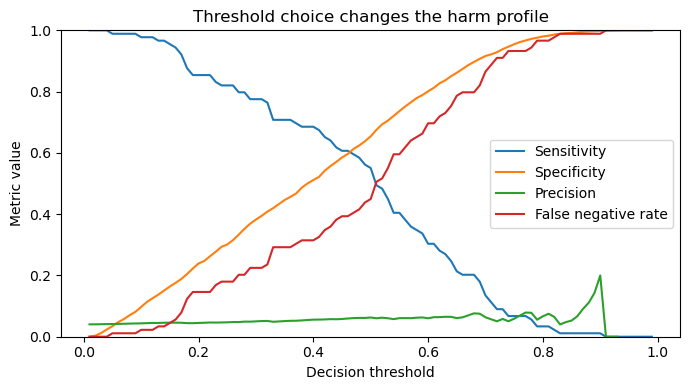

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(threshold_df["threshold"], threshold_df["sensitivity_recall"], label="Sensitivity")
ax.plot(threshold_df["threshold"], threshold_df["specificity"], label="Specificity")
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["false_negative_rate"], label="False negative rate")

ax.set_title("Threshold choice changes the harm profile")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

In [16]:
X_encoded = preprocessor.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_encoded)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "CVD": y.values
})

In [17]:
def plot_pca_distribution(pca_points, labels, title, max_points=5000):
    plot_df = pd.DataFrame({
        "PC1": pca_points[:, 0],
        "PC2": pca_points[:, 1],
        "CVD": np.asarray(labels)
    })

    if len(plot_df) > max_points:
        plot_df = plot_df.sample(max_points, random_state=42)

    fig, ax = plt.subplots(figsize=(6, 5), dpi=200)

    for val, lab, marker in [(0, "No CVD", "."), (1, "CVD", "x")]:
        sub = plot_df[plot_df["CVD"] == val]
        ax.scatter(sub["PC1"], sub["PC2"], s=12, marker=marker, alpha=0.6, label=lab)

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    plt.tight_layout()
    plt.show()

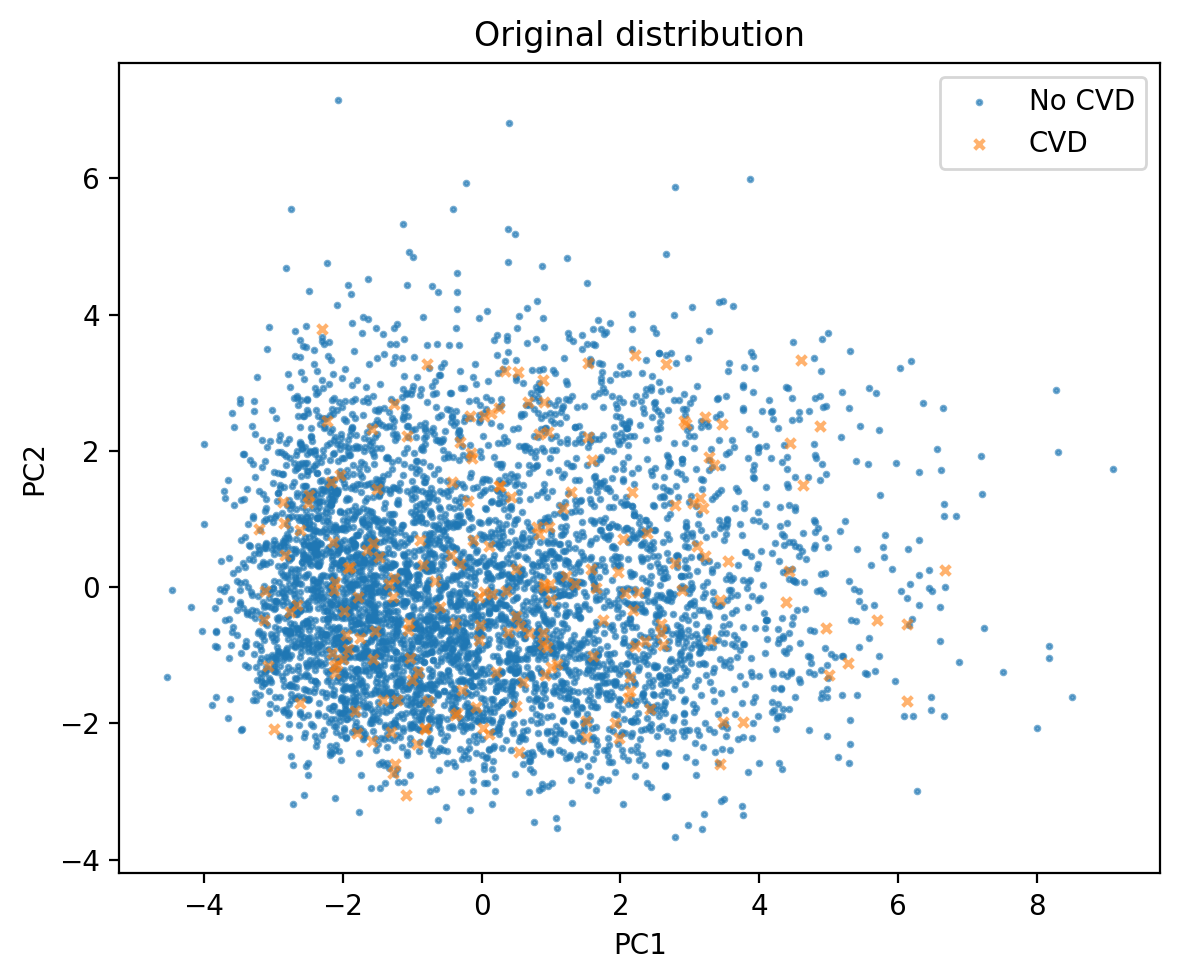

In [18]:
plot_pca_distribution(X_pca, y, "Original distribution")

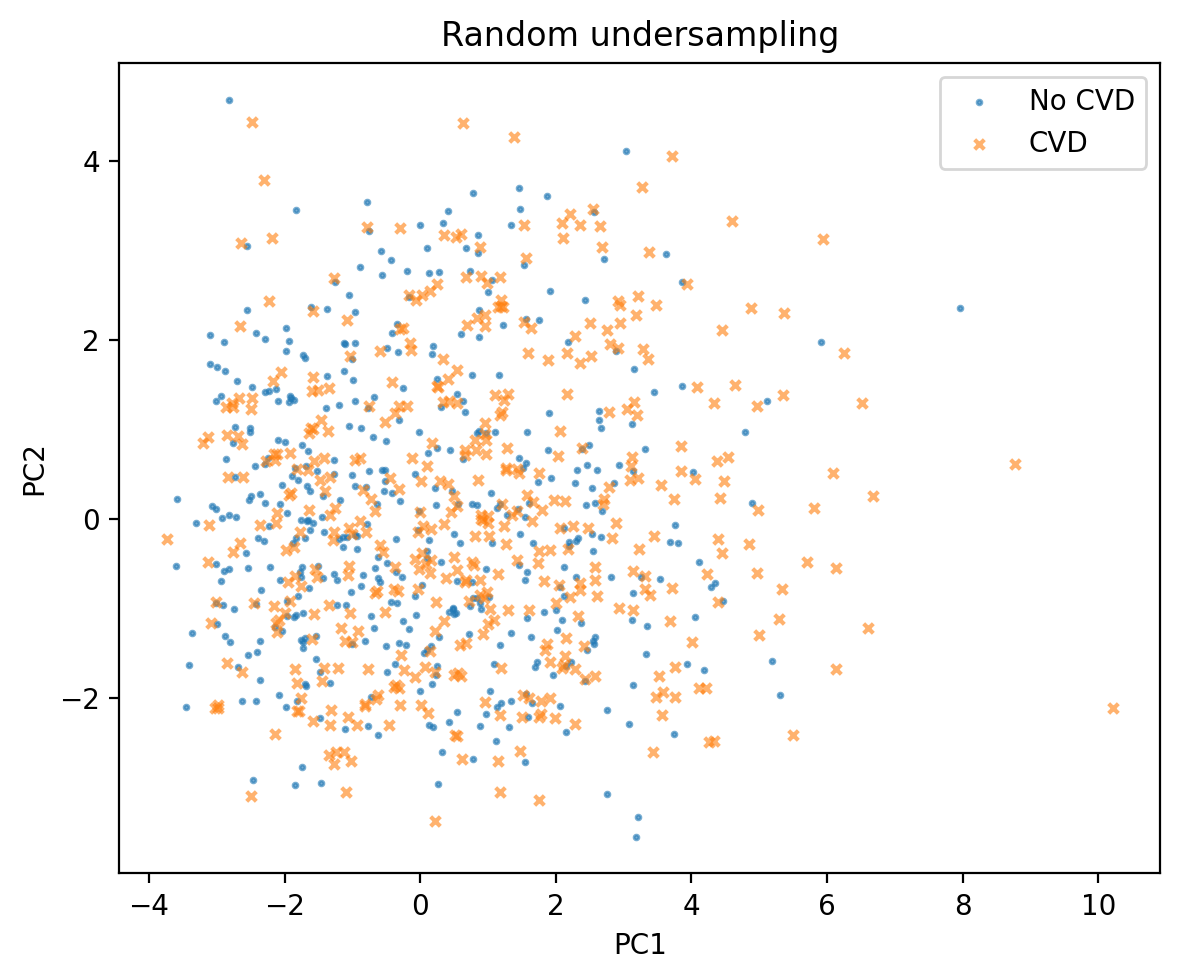

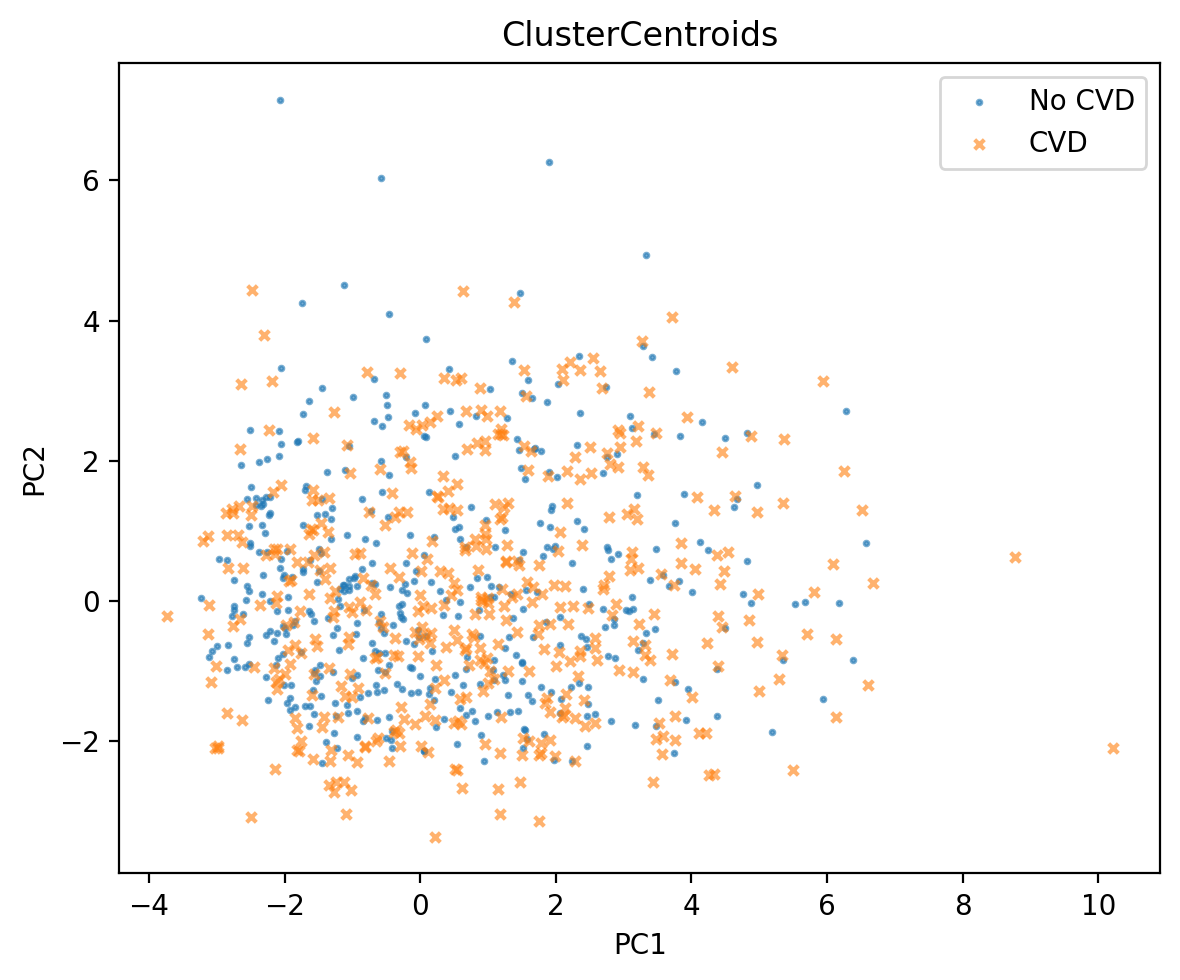

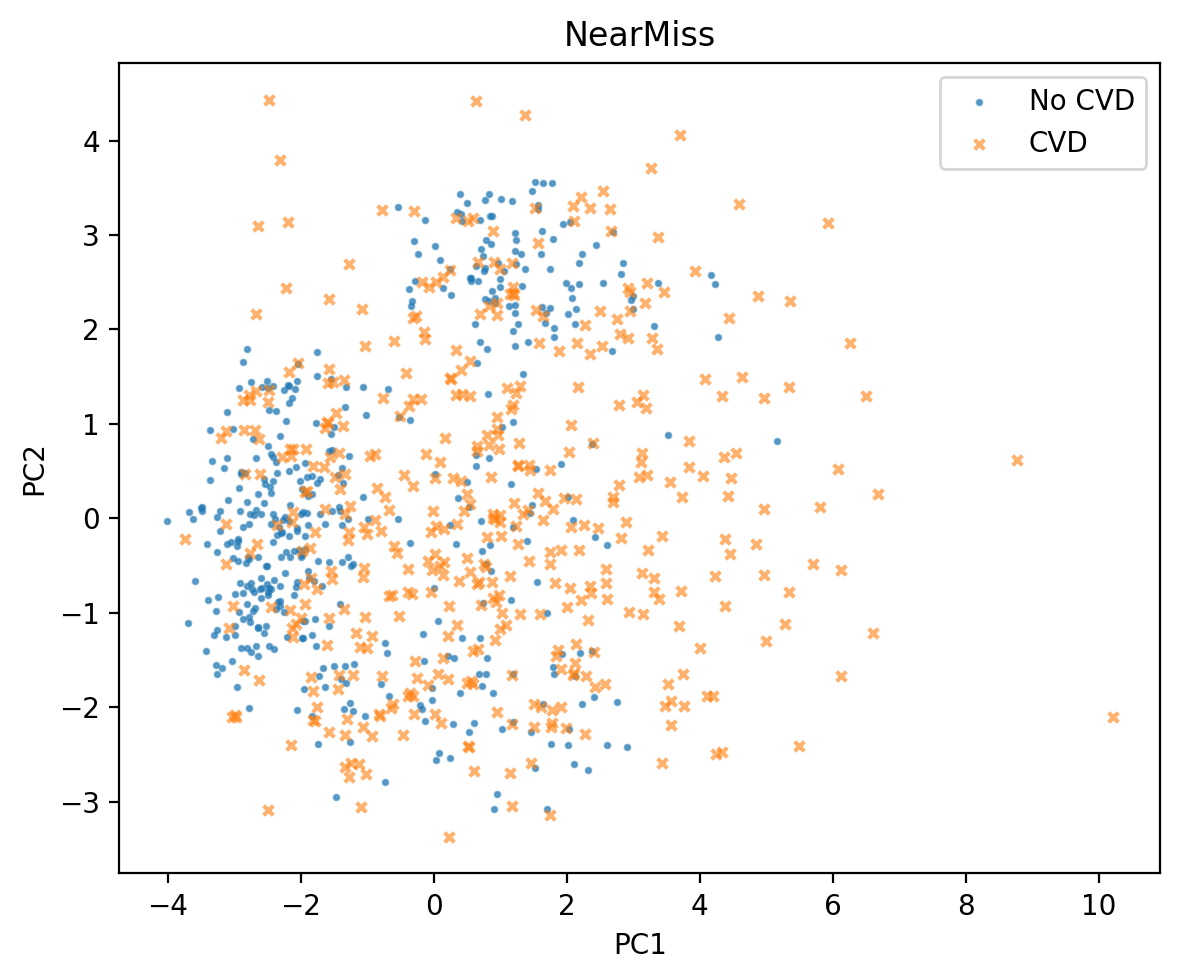

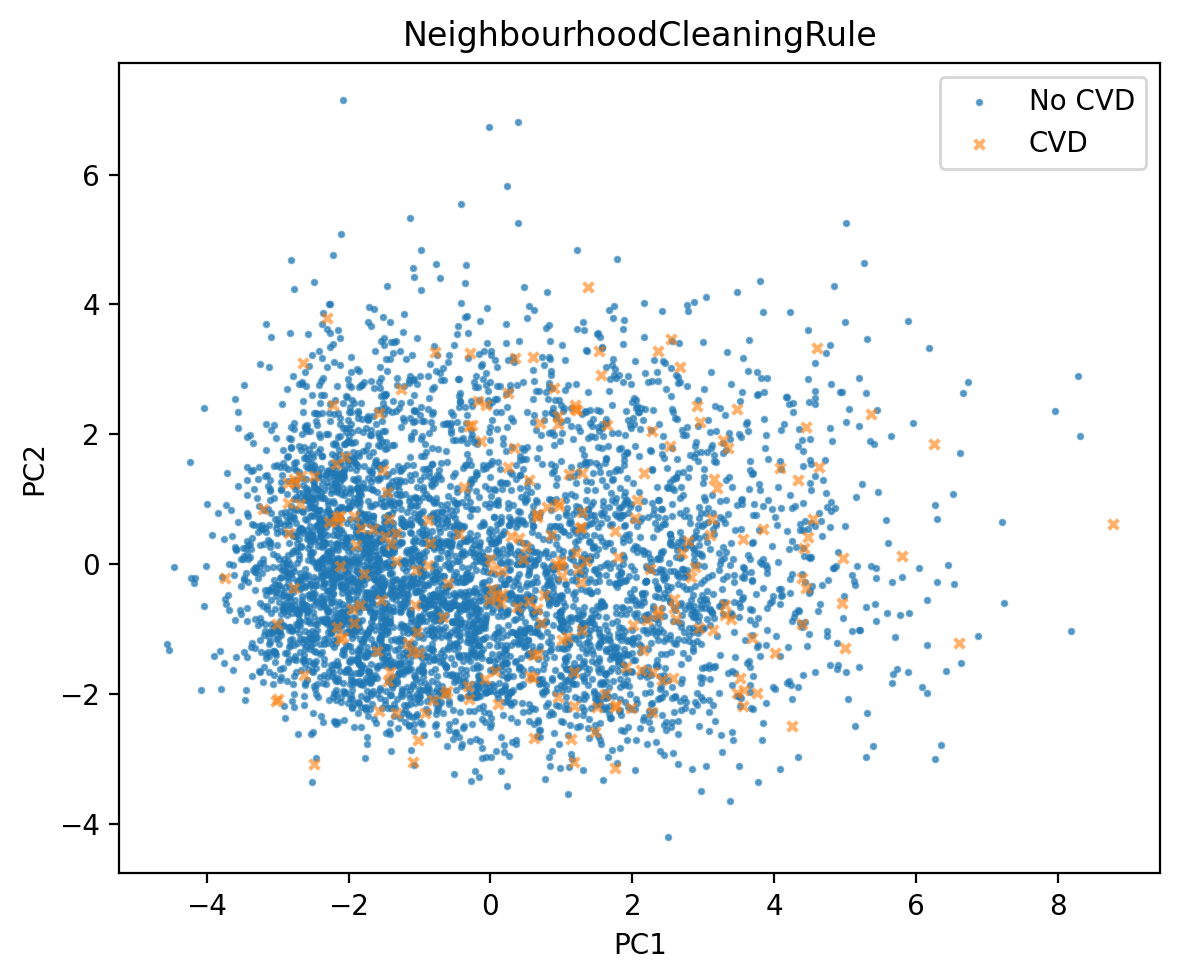

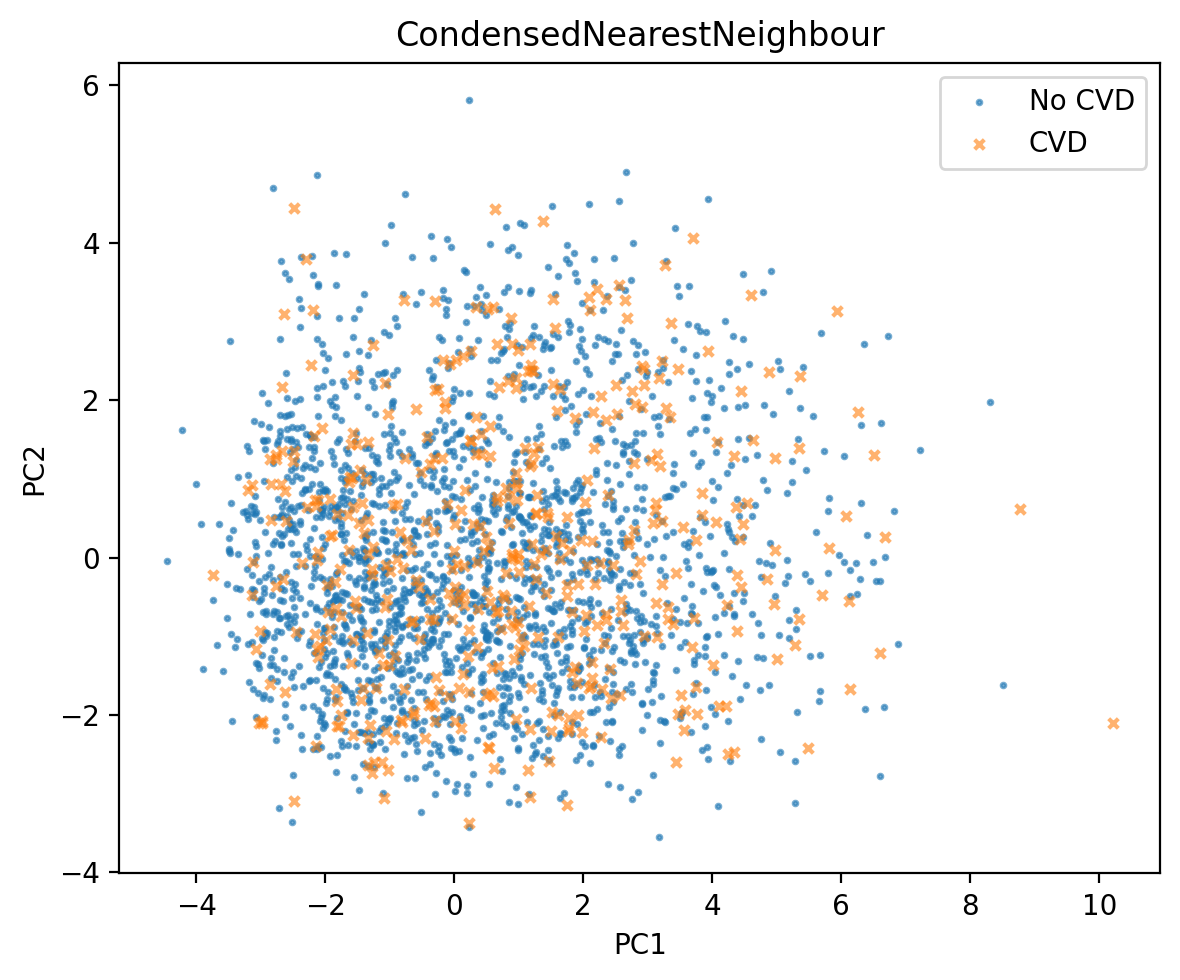

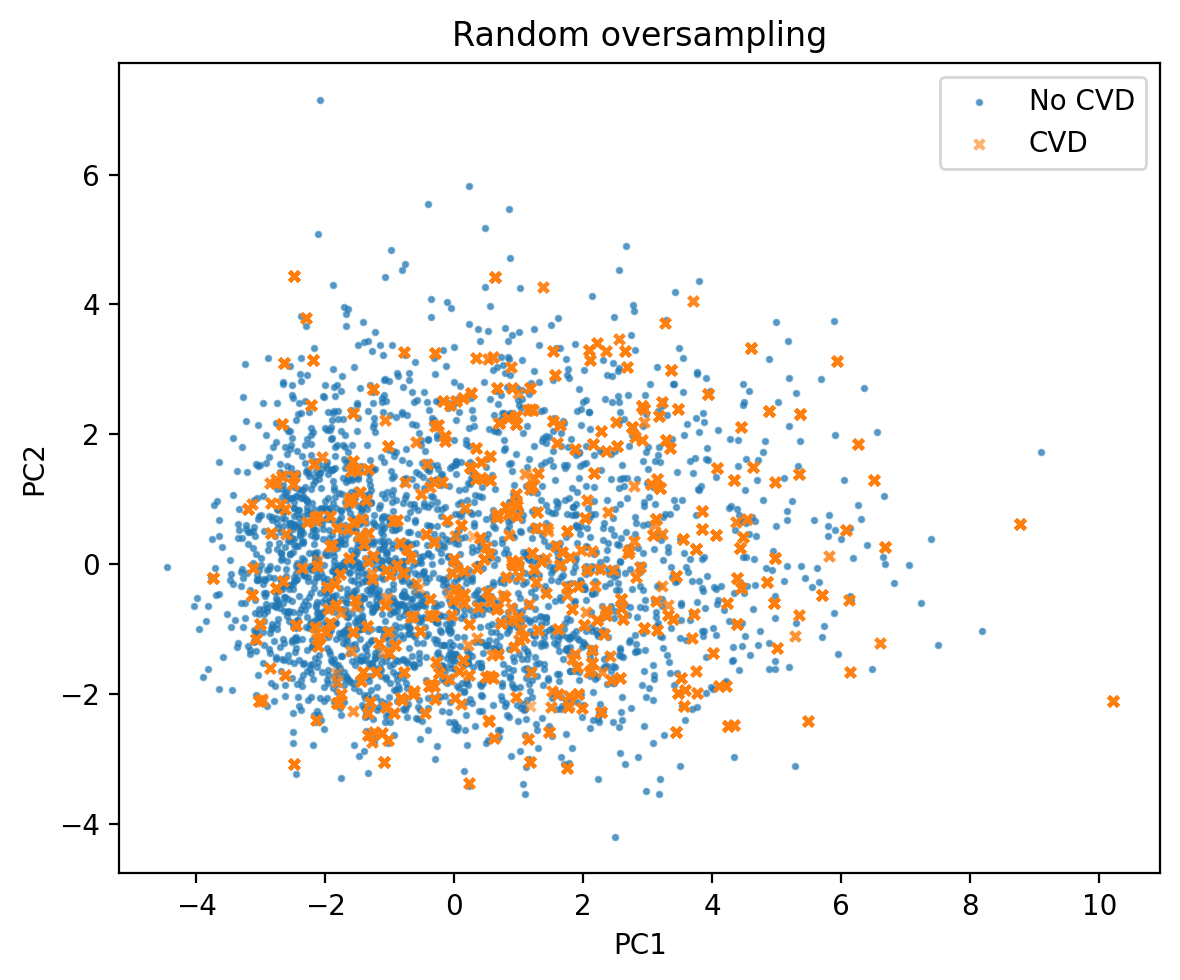

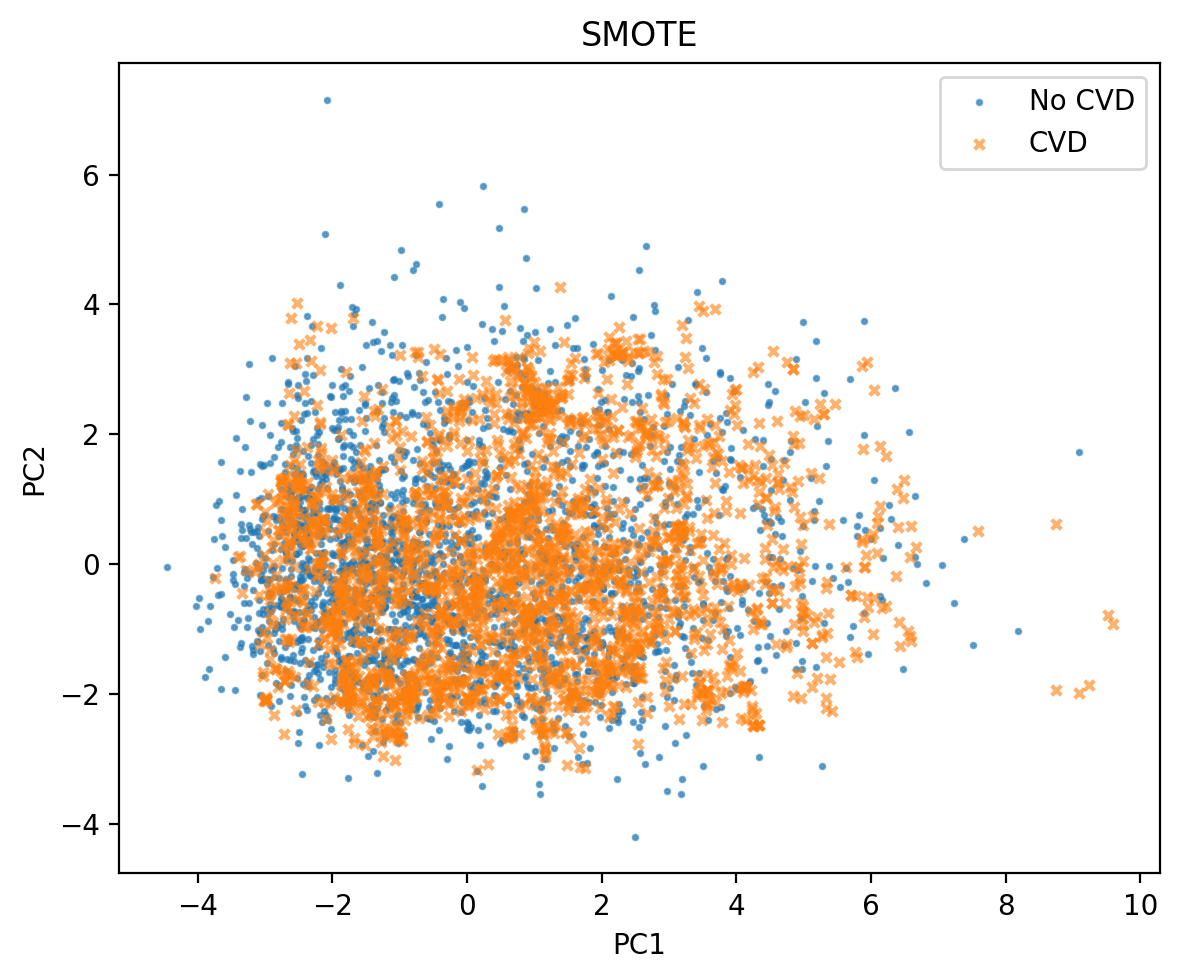

,method,n_total,n_no_cvd,n_cvd,cvd_percent
0,Random undersampling,886,443,443,50.000000
1,ClusterCentroids,886,443,443,50.000000
2,NearMiss,886,443,443,50.000000
3,NeighbourhoodCleaningRule,9882,9439,443,4.482898
4,CondensedNearestNeighbour,2494,2051,443,17.762630
5,Random oversampling,21156,10578,10578,50.000000
6,SMOTE,21156,10578,10578,50.000000


In [19]:
samplers = {
    "Random undersampling": RandomUnderSampler(random_state=42),
    "ClusterCentroids": ClusterCentroids(random_state=42),
    "NearMiss": NearMiss(),
    "NeighbourhoodCleaningRule": NeighbourhoodCleaningRule(),
    "CondensedNearestNeighbour": CondensedNearestNeighbour(random_state=42),
}

if HAS_OVERSAMPLERS:
    samplers["Random oversampling"] = RandomOverSampler(random_state=42)
    samplers["SMOTE"] = SMOTE(random_state=42, k_neighbors=5)

sampling_summary = []

for sampler_name, sampler in samplers.items():
    X_res, y_res = sampler.fit_resample(X_encoded, y)

    # Project resampled data into the original PCA space
    X_res_pca = pca.transform(X_res)

    counts = Counter(y_res)
    sampling_summary.append({
        "method": sampler_name,
        "n_total": len(y_res),
        "n_no_cvd": counts.get(0, 0),
        "n_cvd": counts.get(1, 0),
        "cvd_percent": 100 * counts.get(1, 0) / len(y_res)
    })

    plot_pca_distribution(X_res_pca, y_res, sampler_name)

sampling_summary_df = pd.DataFrame(sampling_summary)
display(sampling_summary_df)

samplers = {
    "Random undersampling": RandomUnderSampler(random_state=42),
    "ClusterCentroids": ClusterCentroids(random_state=42),
    "NearMiss": NearMiss(),
    "NeighbourhoodCleaningRule": NeighbourhoodCleaningRule(),
    "CondensedNearestNeighbour": CondensedNearestNeighbour(random_state=42),
}

if HAS_OVERSAMPLERS:
    samplers["Random oversampling"] = RandomOverSampler(random_state=42)
    samplers["SMOTE"] = SMOTE(random_state=42, k_neighbors=5)

sampling_summary = []

for sampler_name, sampler in samplers.items():
    X_res, y_res = sampler.fit_resample(X_encoded, y)

    # Project resampled data into the original PCA space
    X_res_pca = pca.transform(X_res)

    counts = Counter(y_res)
    sampling_summary.append({
        "method": sampler_name,
        "n_total": len(y_res),
        "n_no_cvd": counts.get(0, 0),
        "n_cvd": counts.get(1, 0),
        "cvd_percent": 100 * counts.get(1, 0) / len(y_res)
    })

    plot_pca_distribution(X_res_pca, y_res, sampler_name)

sampling_summary_df = pd.DataFrame(sampling_summary)
display(sampling_summary_df)